In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import python libraries and kind framework --!

import torch
import numpy as np

from matplotlib import pyplot as plt

import utils_data
import utils_plot

In [2]:
data_nsample = 144
datadir      = '../../data/baselines/m4_test'
data         = utils_data.read_datafile(f'{datadir}/eval', data_nsample)

print(data.shape)

torch.Size([414, 144, 1])


In [3]:
# --! load a trained KIND model --!

model = torch.load('../../models/baselines/m4_h_kind.pt', weights_only=False)
model.eval()

model(
  (operator_stat): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=48, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=1152, bias=True)
          (1): Identity()
        )
      )
    )
    (mod_mean): Linear(in_features=12, out_features=12, bias=False)
    (mod_var_gen): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=24, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=432, bias=True)
          (1): Identity()
        )
      )
    )
    (pre

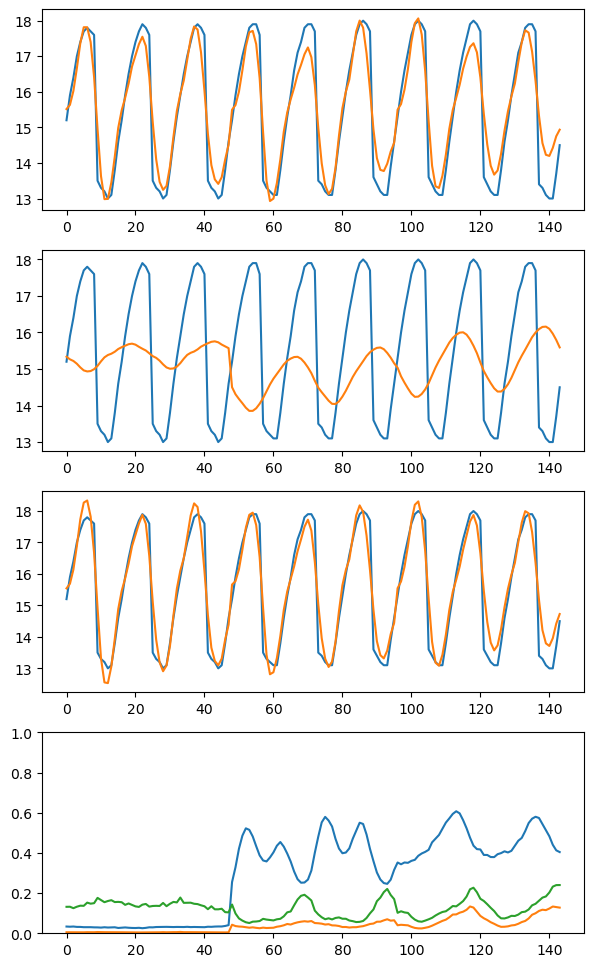

In [20]:
lookback_nsample   = model.lookback_nsample
forecast_nsample   = model.forecast_nsample

jdata = 222 # 44, 88, 123, 222, 256

with torch.no_grad():
    model_i  = data[[jdata], :lookback_nsample, :]
    model_o  = model(model_i)

    blend      = model_o[0]
    stat       = model_o[1]
    stat_zeta  = torch.exp(model_o[2]) + 1e-6
    trans      = model_o[3]
    trans_zeta = torch.exp(model_o[4]) + 1e-6
    alpha      = model_o[9]

    # --! display results --!

    w  = 7
    h  = 3
    nu = 4

    plt.figure(figsize=(w, nu*h))

    plt.subplot(nu, 1, 1)
    plt.plot(data[jdata, :, 0])
    plt.plot(blend[0, :, 0])

    plt.subplot(nu, 1, 2)
    plt.plot(data[jdata, :, 0])
    plt.plot(stat[0, :, 0])

    plt.subplot(nu, 1, 3)
    plt.plot(data[jdata, :, 0])
    plt.plot(trans[0, :, 0])

    stat_zeta_max  = torch.max(stat_zeta)
    trans_zeta_max = torch.max(trans_zeta)
    zeta_max       = stat_zeta_max if stat_zeta_max > trans_zeta_max else trans_zeta_max
    lim_max =      zeta_max if zeta_max > 1.0 else 1.0
    plt.subplot(nu, 1, 4)
    plt.plot(stat_zeta[0, :, 0])
    plt.plot(trans_zeta[0, :, 0])
    plt.plot(alpha[0, :, 0])
    plt.ylim((0, lim_max))

    plt.show()

In [5]:
def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred)

    # Avoid division by zero
    nonzero = denominator != 0
    smape_values = np.zeros_like(diff)
    smape_values[nonzero] = diff[nonzero] / denominator[nonzero]

    return 100 * np.mean(smape_values)

In [6]:
lookback_nsample   = model.lookback_nsample
forecast_nsample   = model.forecast_nsample

true = []
pred = []

ndata = len(data)

with torch.no_grad():
    for j in range(ndata):
        model_i  = data[[j], :lookback_nsample, :]
        model_o  = model(model_i)

        truth = data[[j], lookback_nsample:, :]
        blend = model_o[0][:, lookback_nsample:]

        #plt.figure()
        #plt.plot(truth[0, :, 0])
        #plt.plot(blend[0, :, 0])
        #plt.show()
        #print(tata.shape)

        true.append(truth)
        pred.append(blend)

metric = smape(true, pred)
print(metric)

14.5129795
